In [ ]:
%pip install scikit-learn faiss-cpu

# **Data loading**
This cell loads the sift dataset (10k) and turns the vectors into 2D Numpy Arrays.

In [1]:
#@markdown Fetch SIFT10k dataset
"""SIFT datasets are available at http://corpus-texmex.irisa.fr

The following is just a script for downloading and unzipping SIFT10k
"""

import os, tarfile, urllib.request

if not os.path.exists("siftsmall/siftsmall_base.fvecs"):
    print("Downloading siftsmall.tar.gz...")
    url = "ftp://ftp.irisa.fr/local/texmex/corpus/siftsmall.tar.gz"
    tar_path = "siftsmall.tar.gz"
    urllib.request.urlretrieve(url, tar_path)
    print("Extracting siftsmall/siftsmall_base.fvecs...")
    with tarfile.open(tar_path, "r:gz") as tar:
        for member in tar.getmembers():
            if member.name == "siftsmall/siftsmall_base.fvecs":
                tar.extract(member)
                break
    print("Downloaded and extracted SIFT10k.")
else:
    print("SIFT10k dataset already present at siftsmall/siftsmall_base.fvecs.")


SIFT10k dataset already present at siftsmall/siftsmall_base.fvecs.


In [2]:
"""Save it as a 2D numpy array
N.B Values are just integers coming from a scalar quantization to the [0, 180] interval"""

import numpy as np

def read_fvecs(filename):
  """Reads a .fvecs binary file into a 2D float32 numpy array"""
  data = np.fromfile(filename, dtype='int32')
  dim = data[0] # every vector has a 4-byte header that encodes its dimension

  # Reshape array to (-1, dim + 1), strip dimension column, re-interpret as float32
  return data.reshape(-1, dim + 1)[:, 1:].view('float32')

data = read_fvecs("siftsmall/siftsmall_base.fvecs")
print(f"Loaded SIFT10k dataset with shape: {data.shape}")


Loaded SIFT10k dataset with shape: (10000, 128)


# **Query Generation**
This code generates frequent queries from k clusters (default: 3), each of them ruled by PL distribution.

In [3]:
"""
Generate a set of query vectors on the bounding box (as estimated from data).
Assume a power law query distribution [1]

Reference: [1] https://arxiv.org/pdf/2508.07218
"""

def generate_queries(data, n_queries, exponent,
                     constant, n_clusters=1,
                     random_state=None):

    orig_dtype = data.dtype

    if np.issubdtype(orig_dtype, np.floating) and np.allclose(
        data, np.round(data)):
        data_int = np.round(data).astype(np.int64)
    else:
        data_int = data.astype(np.int64)

    rng = np.random.default_rng(random_state)
    _, d = data_int.shape

    # Bounding box
    L = data_int.min(axis=0)
    U = data_int.max(axis=0)

    # Randomly pick centers within the bounding box
    centers = rng.integers(L, U + 1, size=(n_clusters, d))
    assignments = rng.integers(0, n_clusters, size=n_queries)

    queries = np.empty((n_queries, d), dtype=orig_dtype)

    for k in range(n_clusters):
        mask = assignments == k
        count = np.sum(mask)
        if count == 0:
            continue

        for j in range(d):
            values = np.arange(L[j], U[j] + 1, dtype=np.int64)
            weights = (np.abs(values - centers[k, j]) + constant) ** (
                -float(exponent)
            )
            probs = weights / weights.sum()

            samples = rng.choice(values, size=count, p=probs)
            queries[mask, j] = samples.astype(orig_dtype)

    return queries

query_set = generate_queries(data=data, n_queries=1000, n_clusters=3,
                             exponent=3, constant=2, random_state=67)

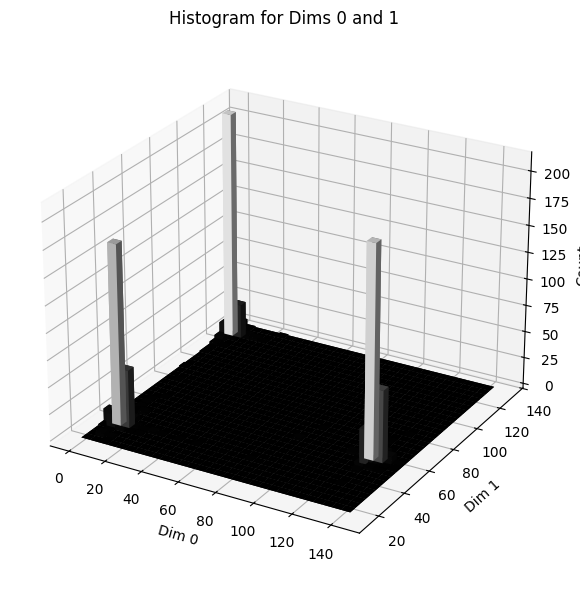

In [4]:
#@markdown 3D Histogram of random dimensions

# """Helper function for visualization of the generated queries"""

import matplotlib.pyplot as plt


def plot_3d_histogram(data, dim_x=0, dim_y=1,
    bins=30, cmap="grey",
    elev=25, azim=-60
):
    x, y = data[:, dim_x], data[:, dim_y]
    hist, xedges, yedges = np.histogram2d(x, y, bins=bins)

    # Use bin lower bounds directly as bar anchors
    xpos, ypos = np.meshgrid(xedges[:-1], yedges[:-1], indexing="ij")
    xpos, ypos, dz = xpos.ravel(), ypos.ravel(), hist.ravel()

    dx = xedges[1] - xedges[0]
    dy = yedges[1] - yedges[0]

    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(8, 6))

    # Color mapping normalized to bar height
    colors = plt.colormaps[cmap](dz / dz.max()) if dz.max() > 0 else "gray"

    ax.bar3d(xpos, ypos, 0, dx, dy, dz, color=colors, shade=True)
    ax.set(
        xlabel=f"Dim {dim_x}",
        ylabel=f"Dim {dim_y}",
        zlabel="Count",
        title=f"Histogram for Dims {dim_x} and {dim_y}",
    )
    ax.view_init(elev=elev, azim=azim)

    return ax

plot_3d_histogram(query_set, dim_x=0, dim_y=1)
plt.tight_layout()
plt.show()

c:\Users\leona\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\leona\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\leona\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\leona\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  

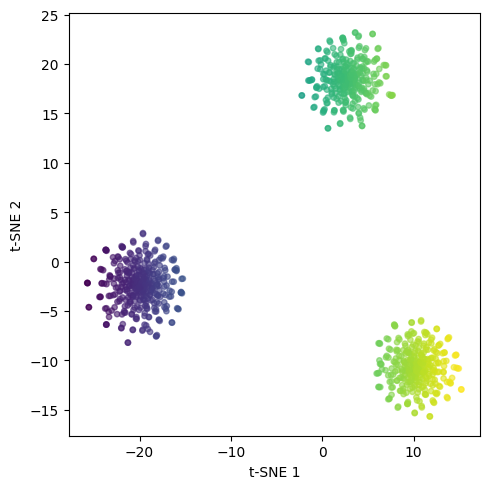

In [5]:
#@markdown T-SNE reduction
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(
    n_components=2,
    perplexity=30.0,
    random_state=67,
)

coords_2d = tsne.fit_transform(query_set)

plt.figure(figsize=(5,5))
plt.scatter(
    coords_2d[:, 0],
    coords_2d[:, 1],
    c=coords_2d[:, 0],
    cmap="viridis",
    s=15,
    alpha=0.6
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

# **Graph Indexing**

### **Cache Creation**

The class creates a cache half dynamic and half static.
- The static part is implemented via `_compute_k_medoids`, where k is obtained as `len(cache)/2`.
- The dynamic part saves the 1-NN obtained via HNSW following LRU (`update_dynamic`).
- Finally, `get_best_entry_point` extracts the nearest element of the query in the cache.

In [6]:
from collections import OrderedDict
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist


class HNSWCache:
    """Gestore della cache ibrida per l'entry point routing in grafi HNSW.

    - Componente Statica (n/2): Medoidi fissi calcolati sul dataset via k-medoids.
    - Componente Dinamica (n/2): Buffer LRU contenente i nodi 1-NN delle query recenti.
    """

    def __init__(
        self, data: np.ndarray, cache_size: int = 64, random_state: int = 42
    ):
        """Inizializza la cache partizionando lo spazio e allocando le risorse.

        :param data: Matrice NumPy contenente l'intero spazio vettoriale.
        :param cache_size: Dimensione totale della cache (N_static + N_dynamic).
        """
        self.data = data
        self.cache_size = cache_size
        self.static_size = cache_size // 2
        self.dynamic_size = cache_size - self.static_size

        # 1. Componente Statica: K-Medoids per ancoraggio globale
        self.static_medoids_indices = self._compute_k_medoids(
            data, self.static_size, random_state
        )

        # 2. Componente Dinamica: LRU implementata tramite OrderedDict {node_id: None}
        self.dynamic_cache = OrderedDict()

    def _compute_k_medoids(
        self, data: np.ndarray, k: int, random_state: int
    ) -> list[int]:
        """Calcola k medoidi reali tramite una versione approssimata basata su K-Means.

        Evita la matrice O(N^2) calcolando i centroids ed estraendo i vettori piu vicini.
        """
        if k <= 0:
            return []

        # Clustering K-Means per estrarre i centroidi
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        kmeans.fit(data)
        centroids = kmeans.cluster_centers_

        # Per ogni centroide, trova l'indice del campioni reale piu vicino (Medoide)
        medoids_indices = []
        for c in centroids:
            # Distanza euclidea tra il centroide c e tutti i punti del dataset
            dists = np.sum((data - c) ** 2, axis=1)
            closest_idx = int(np.argmin(dists))
            medoids_indices.append(closest_idx)

        return medoids_indices

    def update_dynamic(self, node_id: int):
        """Aggiorna la componente LRU con il 1-NN individuato al termine della ricerca HNSW.

        :param node_id: L'indice del nodo (vettore) identificato come 1-NN.
        """
        if node_id in self.static_medoids_indices:
            return  # Evita duplicati se il nodo e gia nella static cache

        if node_id in self.dynamic_cache:
            # Hit: sposta il nodo in fondo (most recently used)
            self.dynamic_cache.move_to_end(node_id)
        else:
            # Miss: inserisci il nuovo nodo evincendo il meno recente (LRU) se pieno
            if len(self.dynamic_cache) >= self.dynamic_size:
                self.dynamic_cache.popitem(last=False)
            self.dynamic_cache[node_id] = None

    def get_best_entry_point(self, query: np.ndarray) -> tuple[int, float, str]:
        """Estrae l'entry point piu vicino alla query considerando sia la cache statica che quella dinamica.

        :return: Tupla (best_node_id, distance_sq, source) dove source e 'static' o 'dynamic'.
        """
        static_candidates = list(self.static_medoids_indices)
        dynamic_candidates = list(self.dynamic_cache.keys())
        all_candidates = static_candidates + dynamic_candidates

        if not all_candidates:
            return 0, float('inf'), 'none'

        # Calcola le distanze euclidee al quadrato tra query e candidati
        dists = np.sum((self.data[all_candidates] - query) ** 2, axis=1)
        best_idx = int(np.argmin(dists))
        source = 'static' if best_idx < len(static_candidates) else 'dynamic'

        return all_candidates[best_idx], float(dists[best_idx]), source


### **HNSW implementation**

This class implements HNSW in order to save the number of hops made to get the 1-NN. 

In [7]:
import heapq
import numpy as np


class InstrumentedHNSW:
    """Implementazione HNSW per tracciare il numero di hops

    e supportare entry point arbitrari (provenienti da cache).
    """

    def __init__(
        self,
        data: np.ndarray,
        M: int = 16,
        ef_construction: int = 40,
        random_state: int = 42,
    ):
        self.data = data
        self.N, self.dim = data.shape
        self.M = M
        self.M0 = 2 * M
        self.ef_construction = ef_construction
        self.mL = 1.0 / np.log(M)
        self.rng = np.random.default_rng(random_state)

        # Struttura del grafo: lista di dizionari per ogni layer {node_id: list_of_neighbors}
        self.layers: list[dict[int, list[int]]] = [{}]
        self.node_levels = np.zeros(self.N, dtype=np.int32)
        self.enter_point: int | None = None
        self.max_level: int = -1

        self._build_index()

    def _dist_sq(self, q: np.ndarray, node_ids: list[int] | int) -> np.ndarray:
        """Distanza euclidea al quadrato vettorizzata."""
        if isinstance(node_ids, (int, np.integer)):
            diff = self.data[node_ids] - q
            return float(np.dot(diff, diff))
        diff = self.data[node_ids] - q
        return np.sum(diff * diff, axis=1)

    def _assign_level(self) -> int:
        """Assegna un livello secondo la distribuzione esponenziale di HNSW."""
        r = self.rng.uniform(1e-9, 1.0)
        return int(-np.log(r) * self.mL)

    def _build_index(self):
        """Costruisce il grafo HNSW inserendo progressivamente tutti i vettori."""
        for i in range(self.N):
            level = self._assign_level()
            self.node_levels[i] = level

            while len(self.layers) <= level:
                self.layers.append({})

            if self.enter_point is None:
                for lc in range(level + 1):
                    self.layers[lc][i] = []
                self.enter_point = i
                self.max_level = level
                continue

            curr_ep = self.enter_point
            q_vec = self.data[i]

            # 1. Greedy descent fino al livello di inserimento
            for lc in range(self.max_level, level, -1):
                changed = True
                curr_dist = self._dist_sq(q_vec, curr_ep)
                while changed:
                    changed = False
                    neighbors = self.layers[lc].get(curr_ep, [])
                    if not neighbors:
                        break
                    dists = self._dist_sq(q_vec, neighbors)
                    min_idx = np.argmin(dists)
                    if dists[min_idx] < curr_dist:
                        curr_dist = dists[min_idx]
                        curr_ep = neighbors[min_idx]
                        changed = True

            # 2. Connessione nei layer da min(level, max_level) a 0
            for lc in range(min(level, self.max_level), -1, -1):
                # Beam search locale per trovare i candidati
                candidates = self._search_layer(
                    q_vec, curr_ep, ef=self.ef_construction, lc=lc
                )
                m_max = self.M0 if lc == 0 else self.M

                # Selezione dei vicini piu prossimi
                cand_ids = [idx for _, idx in candidates]
                cand_dists = self._dist_sq(q_vec, cand_ids)
                best_neighbors = [
                    cand_ids[idx]
                    for idx in np.argsort(cand_dists)[:m_max]
                    if cand_ids[idx] != i
                ]

                self.layers[lc][i] = best_neighbors

                # Connessioni bidirezionali e potatura gradi
                for neighbor in best_neighbors:
                    self.layers[lc].setdefault(neighbor, []).append(i)
                    if len(self.layers[lc][neighbor]) > m_max:
                        n_neighbors = self.layers[lc][neighbor]
                        d = self._dist_sq(self.data[neighbor], n_neighbors)
                        self.layers[lc][neighbor] = [
                            n_neighbors[idx]
                            for idx in np.argsort(d)[:m_max]
                        ]

                curr_ep = candidates[0][1]

            if level > self.max_level:
                self.max_level = level
                self.enter_point = i

    def _search_layer(
        self, q: np.ndarray, ep: int, ef: int, lc: int
    ) -> list[tuple[float, int]]:
        """Esplorazione con priority queue (beam search) per un singolo livello."""
        v_dist = self._dist_sq(q, ep)
        visited = {ep}
        candidates = [(v_dist, ep)]  # min-heap
        w = [(-v_dist, ep)]  # max-heap per tracciare i migliori 'ef'

        while candidates:
            c_dist, c_id = heapq.heappop(candidates)
            furthest_w_dist = -w[0][0]

            if c_dist > furthest_w_dist:
                break

            neighbors = self.layers[lc].get(c_id, [])
            for n in neighbors:
                if n not in visited:
                    visited.add(n)
                    n_dist = self._dist_sq(q, n)
                    if n_dist < furthest_w_dist or len(w) < ef:
                        heapq.heappush(candidates, (n_dist, n))
                        heapq.heappush(w, (-n_dist, n))
                        if len(w) > ef:
                            heapq.heappop(w)

        return sorted([(-d, idx) for d, idx in w])

    def search(
        self,
        query: np.ndarray,
        ef: int = 32,
        custom_entry_id: int | None = None,
        enter_at_layer_zero: bool = False,
    ) -> dict:
        """Esegue la ricerca del 1-NN tracciando gli hop totali percorsi.

        :param custom_entry_id: Nodo di partenza (se None, usa l'entry point globale).
        :param enter_at_layer_zero: Se True, inizia direttamente al Layer 0 saltando i livelli alti.
        """
        hops = 0

        # Determinazione punto e livello di ingresso
        if custom_entry_id is None:
            curr_obj = self.enter_point
            curr_level = self.max_level
        else:
            curr_obj = custom_entry_id
            curr_level = 0 if enter_at_layer_zero else min(self.node_levels[custom_entry_id], self.max_level)

        curr_dist = self._dist_sq(query, curr_obj)

        # 1. Routing greedy sui layer superiori (> 0)
        for lc in range(curr_level, 0, -1):
            changed = True
            while changed:
                changed = False
                neighbors = self.layers[lc].get(curr_obj, [])
                if not neighbors:
                    break
                dists = self._dist_sq(query, neighbors)
                min_idx = np.argmin(dists)
                if dists[min_idx] < curr_dist:
                    curr_dist = dists[min_idx]
                    curr_obj = neighbors[min_idx]
                    hops += 1
                    changed = True

        # 2. Beam search al Layer 0
        visited = {curr_obj}
        candidates = [(curr_dist, curr_obj)]
        w = [(-curr_dist, curr_obj)]

        while candidates:
            c_dist, c_id = heapq.heappop(candidates)
            furthest_w = -w[0][0]

            if c_dist > furthest_w:
                break

            hops += 1  # Hop topologico: conteggio del passo di espansione nodo nel grafo

            neighbors = self.layers[0].get(c_id, [])
            for n in neighbors:
                if n not in visited:
                    visited.add(n)
                    n_dist = self._dist_sq(query, n)

                    if n_dist < furthest_w or len(w) < ef: # almeno 32 hops vengono considerati
                        heapq.heappush(candidates, (n_dist, n))
                        heapq.heappush(w, (-n_dist, n))
                        if len(w) > ef:
                            heapq.heappop(w)

        best_dist, best_node = min((-neg_d, idx) for neg_d, idx in w)
        return {"node": best_node, "distance_sq": best_dist, "hops": hops}


Number of hops Comparison starting from the same query (`query_test`)

In [8]:
# 1. Indicizzazione HNSW (su subset o intero dataset)
hnsw_index = InstrumentedHNSW(data=data, M=16, ef_construction=32, random_state=42)

# 2. Inizializzazione e warm-up della cache con le query sintetiche
cache = HNSWCache(data=data, cache_size=64, random_state=42)

# Warm-up: popola la componente LRU con i primi 100 risultati di query power-law
warmup_queries = query_set[:100]
for q in warmup_queries:
    res = hnsw_index.search(q, ef=32)
    cache.update_dynamic(node_id=res["node"])

# 3. Test comparativo su una query target
test_query = query_set[101]

# Ricerca Standard (Entry Point predefinito al top-layer)
res_standard = hnsw_index.search(test_query, ef=32)

# Ricerca Cache-Assisted (Selezione best entry point da cache -> Layer 0)
best_cached_id, _, ep_source = cache.get_best_entry_point(test_query)
res_cache = hnsw_index.search(
    test_query, ef=32, custom_entry_id=best_cached_id, enter_at_layer_zero=True
)

# 4. Report metriche
print(
    f"{'Metrica':<25} | {'HNSW Standard':<15} | {'HNSW + Cache':<15}\n"
    f"{'-'*60}\n"
    f"{'Entry Point ID':<25} | {str(hnsw_index.enter_point):<15} | {str(best_cached_id) + ' (' + ep_source + ')':<15}\n"
    f"{'1-NN Restituito':<25} | {str(res_standard['node']):<15} | {str(res_cache['node']):<15}\n"
    f"{'Distanza L2 al quadrato':<25} | {res_standard['distance_sq']:<15.2f} | {res_cache['distance_sq']:<15.2f}\n"
    f"{'Totale Hops':<25} | {str(res_standard['hops']):<15} | {str(res_cache['hops']):<15}\n"
    f"{'Hops Risparmiati':<25} | {'0%':<15} | {(1 - res_cache['hops']/res_standard['hops']) * 100:<14.1f}%\n"
    f"{'-'*60}"
)


Metrica                   | HNSW Standard   | HNSW + Cache   
------------------------------------------------------------
Entry Point ID            | 740             | 4060 (dynamic) 
1-NN Restituito           | 4060            | 4060           
Distanza L2 al quadrato   | 481645.00       | 481645.00      
Totale Hops               | 43              | 41             
Hops Risparmiati          | 0%              | 4.7           %
------------------------------------------------------------


# **Experiments**
This section evaluates the routing efficiency of the hybrid-cached HNSW index compared to the standard top-layer entry point approach, focusing on graph traversal hops across varying cache capacities and query workload states.

### 1. **Evaluation Routine**: `benchmark_cache_dynamics`

The` benchmark_cache_dynamics` function measures convergence speed and routing quality by isolating the dynamic cache warmup from evaluation:
Workload Partitioning: Splits the synthetic query workload into a dedicated

- Workload Partitioning: Splits the synthetic query workload into a dedicated validation slice (`test_queries`) and a sequential traffic stream (`stream_queries`).
- Uncached Baseline: Executes standard HNSW greedy traversal (starting from the global top-layer entry point) across the validation set to establish baseline hop counts and true 1-NN retrieval targets.
- Parametric Grid Search: Evaluates multiple total cache capacities ($N \in \{64, 128, 256\}$) across progressive historical stream checkpoints ($0, 25, 50, \dots, 400$ processed queries).
- The metrics extracted are 4:
    - *Mean Traversal Hops*: Average edge transitions required to reach the terminal 1-NN candidate.
    - *Hop Reduction* (%): Relative percentage of traversal steps saved compared to baseline HNSW.
    - *Recall vs. Standard* (%): Consistency rate of the returned 1-NN relative to standard HNSW, ensuring direct Layer-0 entry points do not induce local minima traps.
    - *LRU Utilization* (%): Dynamic buffer saturation level.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt


def benchmark_cache_dynamics(
    hnsw_index: InstrumentedHNSW,
    data: np.ndarray,
    queries: np.ndarray,
    cache_sizes: list[int] = [64, 128, 256],
    checkpoints: list[int] = [0, 25, 50, 100, 200, 400],
    n_test_queries: int = 100,
    ef_search: int = 32
):
    """
    Misura gli hop medi al variare della capacita della cache e dello stato
    di popolamento della componente dinamica. Traccia inoltre l'utilizzo effettivo
    della cache dinamica durante le ricerche.
    """
    # 1. Separazione tra stream di warmup/traffico e pool di validazione
    test_queries = queries[:n_test_queries]
    stream_queries = queries[n_test_queries:]

    max_checkpoint = max(checkpoints)
    if len(stream_queries) < max_checkpoint:
        raise ValueError(f"Servono almeno {max_checkpoint + n_test_queries} query totali.")

    # 2. Baseline HNSW standard (indipendente dalla cache)
    std_hops = []
    std_results = []
    for q in test_queries:
        res = hnsw_index.search(q, ef=ef_search)
        std_hops.append(res["hops"])
        std_results.append(res["node"])

    baseline_avg_hops = float(np.mean(std_hops))
    print(f"[*] Baseline HNSW (Senza Cache): {baseline_avg_hops:.2f} hop medi\n")

    records = []

    # 3. Griglia di test: Cache Size x Checkpoints di query eseguite
    for c_size in cache_sizes:
        print(f"--- Valutazione Cache Size = {c_size} ---")
        cache = HNSWCache(data=data, cache_size=c_size, random_state=42)
        stream_ptr = 0

        for cp in checkpoints:
            # Avanza lo stream fino al checkpoint corrente aggiornando la LRU
            while stream_ptr < cp:
                q_stream = stream_queries[stream_ptr]
                best_ep, _, _ = cache.get_best_entry_point(q_stream)
                res_stream = hnsw_index.search(
                    q_stream,
                    ef=ef_search,
                    custom_entry_id=best_ep,
                    enter_at_layer_zero=True
                )
                cache.update_dynamic(node_id=res_stream["node"])
                stream_ptr += 1

            # Valutazione sul test set al checkpoint attuale
            test_hops = []
            matching_hits = 0
            dynamic_hits = 0

            for idx, q in enumerate(test_queries):
                best_ep, _, source = cache.get_best_entry_point(q)
                if source == 'dynamic':
                    dynamic_hits += 1

                res = hnsw_index.search(
                    q,
                    ef=ef_search,
                    custom_entry_id=best_ep,
                    enter_at_layer_zero=True
                )
                test_hops.append(res["hops"])

                # Controllo coerenza del 1-NN rispetto alla baseline standard
                if res["node"] == std_results[idx]:
                    matching_hits += 1

            avg_hops = float(np.mean(test_hops))
            hop_delta_pct = (1.0 - (avg_hops / baseline_avg_hops)) * 100.0
            recall_vs_std = (matching_hits / n_test_queries) * 100.0
            dynamic_usage_pct = (dynamic_hits / n_test_queries) * 100.0

            records.append({
                "Cache Size": c_size,
                "Query Eseguite": cp,
                "Hop Medi": round(avg_hops, 2),
                "Hop Risparmiati (%)": round(hop_delta_pct, 1),
                "Recall vs Std (%)": round(recall_vs_std, 1),
                "Uso Cache Dinamica (%)": round(dynamic_usage_pct, 1),
                "Effective dynamic cache size (%)": round((len(cache.dynamic_cache) / cache.dynamic_size) * 100.0, 1)
            })

    results_df = pd.DataFrame(records)
    return results_df, baseline_avg_hops

### 2. **Pipeline Execution & Convergence Plotting**

The execution block runs the parameter sweep and visualizes the interaction between static coverage and dynamic adaptation:


*   Tabular Aggregation: Summarizes retrieval metrics in a pandas.DataFrame across all combinations of cache capacity and warm-up milestones.
*   Trajectory Visualization: Plots mean hop trajectories against the number of historical stream queries, with a dashed reference line for the baseline HNSW cost.
* Dynamics Captured: **Checkpoint 0 (Cold Start)**: Reflects hop reduction achieved purely through static Voronoi coverage via the $k$-medoids subset ($k = N / 2$). **Transient Phase**: Captures the steep drop in hops as power-law query clusters populate the dynamic LRU cache, enabling near-immediate convergence to target local graph neighborhoods. **Steady State**: Identifies the saturation plateau and highlights potential LRU thrashing when cluster variety exceeds dynamic capacity.

In [ ]:
print(len(query_set))
print(len(hnsw_index.layers[2]))

1000
39


In [10]:
import pandas as pd
import matplotlib.pyplot as plt


def benchmark_cache_dynamics(
    hnsw_index: InstrumentedHNSW,
    data: np.ndarray,
    queries: np.ndarray,
    cache_sizes: list[int] = [64, 128, 256],
    checkpoints: list[int] = [0, 25, 50, 100, 200, 400],
    n_test_queries: int = 100,
    ef_search: int = 32
):
    """
    Misura gli hop medi, il tasso di utilizzo della cache dinamica e la qualita del 1-NN trovato
    rispetto all'1-NN reale di Ground Truth (calcolato via ricerca esaustiva K-NN).
    """
    # 1. Separazione tra stream di warmup/traffico e pool di validazione
    test_queries = queries[:n_test_queries] # query usate per il test di valutazione
    stream_queries = queries[n_test_queries:] # query usate per il popolamento della cache

    max_checkpoint = max(checkpoints)
    if len(stream_queries) < max_checkpoint:
        raise ValueError(f"Servono almeno {max_checkpoint + n_test_queries} query totali.")

    # 2. Calcolo del Ground Truth Reale (1-NN esaustivo tramite K-NN su tutto il dataset)
    gt_nodes = []
    gt_dists = []
    for q in test_queries:
        dists = np.sum((data - q) ** 2, axis=1)
        best_i = int(np.argmin(dists))
        gt_nodes.append(best_i)
        gt_dists.append(float(dists[best_i]))

    gt_nodes = np.array(gt_nodes)
    gt_dists = np.array(gt_dists)
    gt_mean_dist = float(np.mean(gt_dists))

    # 3. Baseline HNSW standard (indipendente dalla cache)
    std_hops = []
    std_results = []
    std_dists = []
    for q in test_queries:
        res = hnsw_index.search(q, ef=ef_search)
        std_hops.append(res["hops"])
        std_results.append(res["node"])
        std_dists.append(res["distance_sq"])

    std_nodes = np.array(std_results)
    std_dists = np.array(std_dists)
    baseline_avg_hops = float(np.mean(std_hops))
    std_recall_gt = float(np.mean(std_nodes == gt_nodes) * 100.0)
    std_mean_dist = float(np.mean(std_dists))

    print(f"[*] Baseline HNSW (Senza Cache): {baseline_avg_hops:.2f} hop medi | Recall vs GT Reale: {std_recall_gt:.1f}% | Dist L2 Media: {std_mean_dist:.2f} (Dist GT: {gt_mean_dist:.2f})\n")

    records = []

    # 4. Griglia di test: Cache Size x Checkpoints di query eseguite
    for c_size in cache_sizes:
        print(f"--- Valutazione Cache Size = {c_size} ---")
        cache = HNSWCache(data=data, cache_size=c_size, random_state=42)
        stream_ptr = 0

        for cp in checkpoints:
            # Avanza lo stream fino al checkpoint corrente aggiornando la LRU
            while stream_ptr < cp:
                q_stream = stream_queries[stream_ptr]
                best_ep, _, _ = cache.get_best_entry_point(q_stream)
                res_stream = hnsw_index.search(
                    q_stream,
                    ef=ef_search,
                    custom_entry_id=best_ep,
                    enter_at_layer_zero=True
                )
                cache.update_dynamic(node_id=res_stream["node"])
                stream_ptr += 1

            # Valutazione sul test set al checkpoint attuale
            test_hops = []
            test_nodes = []
            test_dists = []
            dynamic_hits = 0

            for idx, q in enumerate(test_queries):
                best_ep, _, source = cache.get_best_entry_point(q)
                if source == 'dynamic':
                    dynamic_hits += 1

                res = hnsw_index.search(
                    q,
                    ef=ef_search,
                    custom_entry_id=best_ep,
                    enter_at_layer_zero=True
                )
                test_hops.append(res["hops"])
                test_nodes.append(res["node"])
                test_dists.append(res["distance_sq"])

            test_nodes = np.array(test_nodes)
            test_dists = np.array(test_dists)

            avg_hops = float(np.mean(test_hops))
            hop_delta_pct = (1.0 - (avg_hops / baseline_avg_hops)) * 100.0
            recall_vs_std = float(np.mean(test_nodes == std_nodes) * 100.0)
            recall_vs_gt = float(np.mean(test_nodes == gt_nodes) * 100.0)
            dist_ratio_gt = float(np.mean(test_dists / gt_dists))
            dynamic_usage_pct = (dynamic_hits / n_test_queries) * 100.0

            records.append({
                "Cache Size": c_size,
                "Query Eseguite": cp,
                "Hop Medi": round(avg_hops, 2),
                "Hop Risparmiati (%)": round(hop_delta_pct, 1),
                "Recall vs Std (%)": round(recall_vs_std, 1),
                "Recall vs GT Reale (%)": round(recall_vs_gt, 1),
                "Dist Ratio vs GT": round(dist_ratio_gt, 4),
                "Uso Cache Dinamica (%)": round(dynamic_usage_pct, 1),
                "Effective dynamic cache size (%)": round((len(cache.dynamic_cache) / cache.dynamic_size) * 100.0, 1)
            })

    results_df = pd.DataFrame(records)
    return results_df, baseline_avg_hops


In [ ]:
# Cell debug disabilitato
# np.all(query_set_debug == query_set_debug[0])

[*] Baseline HNSW (Senza Cache): 38.69 hop medi | Recall vs GT Reale: 0.0% | Dist L2 Media: 557529.49 (Dist GT: 513296.86)

--- Valutazione Cache Size = 64 ---
--- Valutazione Cache Size = 128 ---
--- Valutazione Cache Size = 256 ---


,Cache Size,Query Eseguite,Hop Medi,Hop Risparmiati (%),Recall vs Std (%),Recall vs GT Reale (%),Dist Ratio vs GT,Uso Cache Dinamica (%),Effective dynamic cache size (%)
0,64,1,32.73,15.4,0.0,84.0,1.0005,100.0,3.1
1,64,25,33.17,14.3,0.0,84.0,1.0005,100.0,6.2
2,64,50,33.17,14.3,0.0,84.0,1.0005,100.0,6.2
3,64,100,33.17,14.3,0.0,84.0,1.0005,100.0,6.2
4,64,200,33.17,14.3,0.0,84.0,1.0005,100.0,12.5
5,64,400,33.17,14.3,0.0,100.0,1.0000,100.0,18.8
6,128,1,33.23,14.1,27.0,57.0,1.0065,27.0,1.6
7,128,25,33.17,14.3,0.0,84.0,1.0005,99.0,4.7
8,128,50,33.17,14.3,0.0,84.0,1.0005,99.0,4.7
9,128,100,33.17,14.3,0.0,84.0,1.0005,99.0,4.7


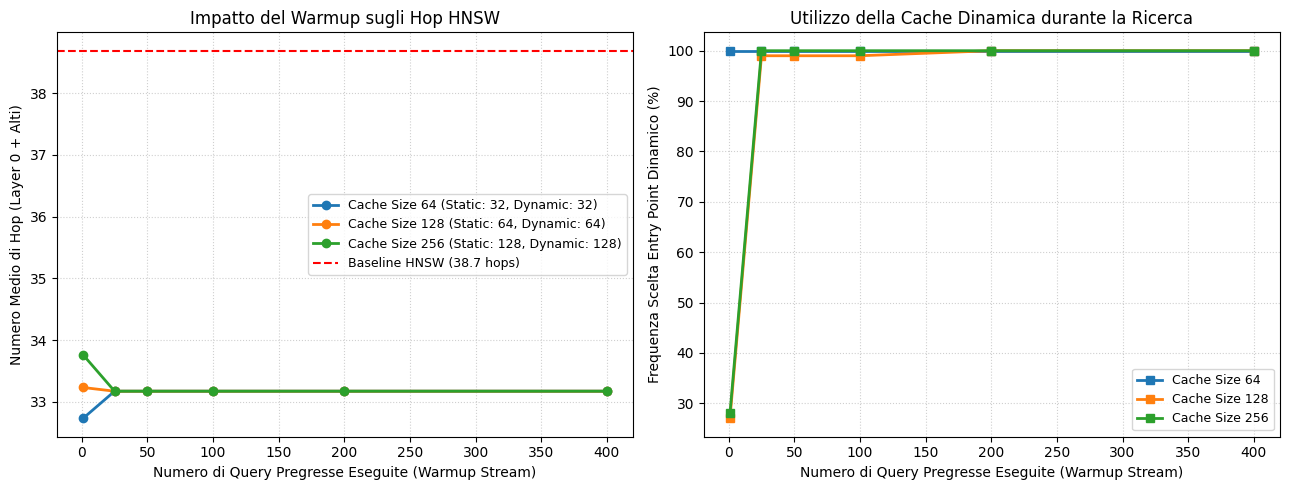

In [11]:
# Esecuzione del benchmark
checkpoints_list = [1, 25, 50, 100, 200, 400]
cache_sizes_list = [64, 128, 256]

df_results, baseline_hops = benchmark_cache_dynamics(
    hnsw_index=hnsw_index,
    data=data,
    queries=query_set, # query_set contiene sia le query di warmup che quelle di test
    cache_sizes=cache_sizes_list,
    checkpoints=checkpoints_list,
    n_test_queries=100, # numero di query di test per valutare le metriche
    ef_search=32
)

# Visualizzazione tabellare
display(df_results)

# Plot delle curve di convergenza e dell'uso della cache dinamica
plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
for c_size in cache_sizes_list:
    subset = df_results[df_results["Cache Size"] == c_size]
    plt.plot(
        subset["Query Eseguite"],
        subset["Hop Medi"],
        marker='o',
        linewidth=2,
        label=f"Cache Size {c_size} (Static: {c_size//2}, Dynamic: {c_size//2})"
    )

plt.axhline(
    y=baseline_hops,
    color='r',
    linestyle='--',
    linewidth=1.5,
    label=f"Baseline HNSW ({baseline_hops:.1f} hops)"
)

plt.title("Impatto del Warmup sugli Hop HNSW", fontsize=12)
plt.xlabel("Numero di Query Pregresse Eseguite (Warmup Stream)", fontsize=10)
plt.ylabel("Numero Medio di Hop (Layer 0 + Alti)", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=9)

plt.subplot(1, 2, 2)
for c_size in cache_sizes_list:
    subset = df_results[df_results["Cache Size"] == c_size]
    plt.plot(
        subset["Query Eseguite"],
        subset["Uso Cache Dinamica (%)"],
        marker='s',
        linewidth=2,
        label=f"Cache Size {c_size}"
    )

plt.title("Utilizzo della Cache Dinamica durante la Ricerca", fontsize=12)
plt.xlabel("Numero di Query Pregresse Eseguite (Warmup Stream)", fontsize=10)
plt.ylabel("Frequenza Scelta Entry Point Dinamico (%)", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=9)

plt.tight_layout()
plt.show()


### 3. **Analysis of the impact of Dynamic Cache Size (Total Cache size is fixed)**

This section analyzes the performance in terms of average hops w.r.t. the proportion of dynamic cache. The idea is that, fixing the cache size (e.g., $C = 64$), we can obtain good performances even is the dynamic part is reduced.


,Dim. Totale Cache,Dim. Statica,Dim. Dinamica,Hop Medi,Hop Risparmiati (%),Uso Cache Dinamica (%),Uso Cache Statica (%)
0,64,64,0,33.31,13.9,0.0,100.0
1,64,60,4,36.89,4.7,100.0,0.0
2,64,56,8,33.17,14.3,100.0,0.0
3,64,48,16,36.89,4.7,100.0,0.0
4,64,32,32,33.17,14.3,100.0,0.0
5,64,16,48,36.89,4.7,100.0,0.0
6,64,0,64,33.17,14.3,100.0,0.0


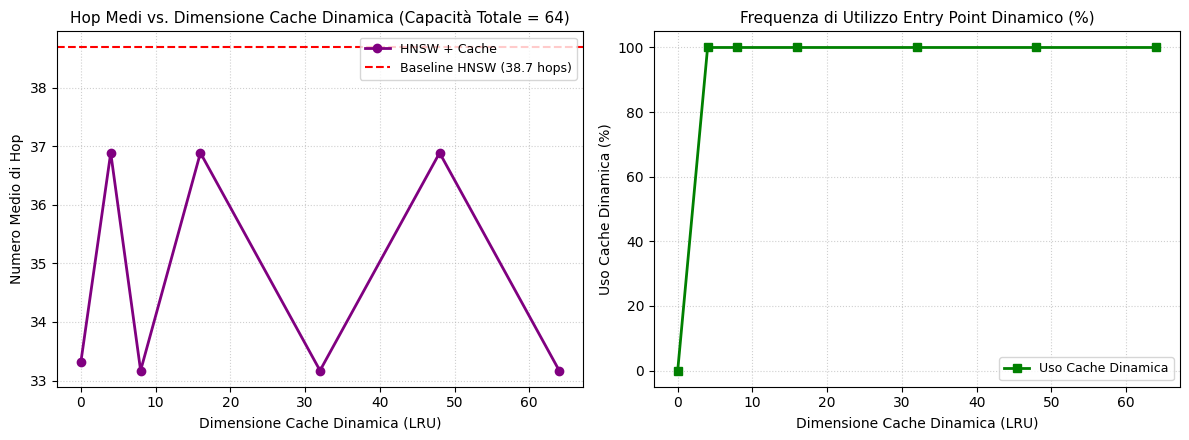

In [12]:
# Analisi della variazione della dimensione della cache dinamica per una capacità totale fissata (es. 64)
import pandas as pd
import matplotlib.pyplot as plt


class CustomSplitCache:
    def __init__(self, data: np.ndarray, static_size: int, dynamic_size: int, random_state: int = 42):
        self.data = data
        self.static_size = static_size
        self.dynamic_size = dynamic_size
        
        if static_size > 0:
            kmeans = KMeans(n_clusters=static_size, random_state=random_state, n_init=10)
            kmeans.fit(data)
            centroids = kmeans.cluster_centers_
            self.static_medoids_indices = [int(np.argmin(np.sum((data - c) ** 2, axis=1))) for c in centroids]
        else:
            self.static_medoids_indices = []
            
        self.dynamic_cache = OrderedDict()

    def update_dynamic(self, node_id: int):
        if node_id in self.static_medoids_indices or self.dynamic_size <= 0:
            return
        if node_id in self.dynamic_cache:
            self.dynamic_cache.move_to_end(node_id)
        else:
            if len(self.dynamic_cache) >= self.dynamic_size:
                self.dynamic_cache.popitem(last=False)
            self.dynamic_cache[node_id] = None

    def get_best_entry_point(self, query: np.ndarray) -> tuple[int, float, str]:
        static_candidates = list(self.static_medoids_indices)
        dynamic_candidates = list(self.dynamic_cache.keys())
        all_candidates = static_candidates + dynamic_candidates

        if not all_candidates:
            return 0, float('inf'), 'none'

        dists = np.sum((self.data[all_candidates] - query) ** 2, axis=1)
        best_idx = int(np.argmin(dists))
        source = 'static' if best_idx < len(static_candidates) else 'dynamic'
        return all_candidates[best_idx], float(dists[best_idx]), source


def benchmark_dynamic_splits(
    hnsw_index: InstrumentedHNSW,
    data: np.ndarray,
    queries: np.ndarray,
    fixed_total_capacity: int = 64,
    dynamic_sizes: list[int] = [0, 4, 8, 16, 32, 48, 64],
    warmup_queries_count: int = 400,
    n_test_queries: int = 100
):
    test_queries = queries[:n_test_queries]
    warmup_queries = queries[n_test_queries:n_test_queries + warmup_queries_count]

    std_hops = [hnsw_index.search(q, ef=32)["hops"] for q in test_queries]
    baseline_avg_hops = float(np.mean(std_hops))

    records = []

    for dyn_size in dynamic_sizes:
        stat_size = max(0, fixed_total_capacity - dyn_size)
        cache = CustomSplitCache(data=data, static_size=stat_size, dynamic_size=dyn_size, random_state=42)

        # Warmup stream
        for q in warmup_queries:
            best_ep, _, _ = cache.get_best_entry_point(q)
            res = hnsw_index.search(q, ef=32, custom_entry_id=best_ep, enter_at_layer_zero=True)
            cache.update_dynamic(res["node"])

        # Evaluation
        test_hops = []
        dynamic_hits = 0
        static_hits = 0

        for q in test_queries:
            best_ep, _, source = cache.get_best_entry_point(q)
            if source == 'dynamic':
                dynamic_hits += 1
            elif source == 'static':
                static_hits += 1

            res = hnsw_index.search(q, ef=32, custom_entry_id=best_ep, enter_at_layer_zero=True)
            test_hops.append(res["hops"])

        avg_hops = float(np.mean(test_hops))
        records.append({
            "Dim. Totale Cache": fixed_total_capacity,
            "Dim. Statica": stat_size,
            "Dim. Dinamica": dyn_size,
            "Hop Medi": round(avg_hops, 2),
            "Hop Risparmiati (%)": round((1.0 - avg_hops / baseline_avg_hops) * 100.0, 1),
            "Uso Cache Dinamica (%)": round(dynamic_hits / n_test_queries * 100.0, 1),
            "Uso Cache Statica (%)": round(static_hits / n_test_queries * 100.0, 1)
        })

    return pd.DataFrame(records), baseline_avg_hops


# Esecuzione del benchmark al variare della dimensione dinamica (Capacità totale = 64)
df_split, baseline_hops_split = benchmark_dynamic_splits(
    hnsw_index=hnsw_index,
    data=data,
    queries=query_set,
    fixed_total_capacity=64,
    dynamic_sizes=[0, 4, 8, 16, 32, 48, 64]
)

display(df_split)

# Grafico delle performance in termini di Hop al variare della dimensione dinamica
plt.figure(figsize=(12, 4.5))

plt.subplot(1, 2, 1)
plt.plot(df_split["Dim. Dinamica"], df_split["Hop Medi"], marker='o', color='purple', linewidth=2, label="HNSW + Cache")
plt.axhline(y=baseline_hops_split, color='r', linestyle='--', linewidth=1.5, label=f"Baseline HNSW ({baseline_hops_split:.1f} hops)")
plt.title("Hop Medi vs. Dimensione Cache Dinamica (Capacità Totale = 64)", fontsize=11)
plt.xlabel("Dimensione Cache Dinamica (LRU)", fontsize=10)
plt.ylabel("Numero Medio di Hop", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=9)

plt.subplot(1, 2, 2)
plt.plot(df_split["Dim. Dinamica"], df_split["Uso Cache Dinamica (%)"], marker='s', color='green', linewidth=2, label="Uso Cache Dinamica")
plt.title("Frequenza di Utilizzo Entry Point Dinamico (%)", fontsize=11)
plt.xlabel("Dimensione Cache Dinamica (LRU)", fontsize=10)
plt.ylabel("Uso Cache Dinamica (%)", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=9)

plt.tight_layout()
plt.show()


[*] Baseline HNSW (Senza Cache): 38.69 hop medi | Recall vs GT Reale: 0.0% | Dist L2 Media: 557529.49 (Dist GT: 513296.86)

--- Valutazione Cache Size = 64 ---
--- Valutazione Cache Size = 128 ---
--- Valutazione Cache Size = 256 ---


,Cache Size,Query Eseguite,Hop Medi,Hop Risparmiati (%),Recall vs Std (%),Recall vs GT Reale (%),Dist Ratio vs GT,Uso Cache Dinamica (%),Effective dynamic cache size (%)
0,64,1,32.73,15.4,0.0,84.0,1.0005,100.0,3.1
1,64,25,33.17,14.3,0.0,84.0,1.0005,100.0,6.2
2,64,50,33.17,14.3,0.0,84.0,1.0005,100.0,6.2
3,64,100,33.17,14.3,0.0,84.0,1.0005,100.0,6.2
4,64,200,33.17,14.3,0.0,84.0,1.0005,100.0,12.5
5,64,400,33.17,14.3,0.0,100.0,1.0000,100.0,18.8
6,128,1,33.23,14.1,27.0,57.0,1.0065,27.0,1.6
7,128,25,33.17,14.3,0.0,84.0,1.0005,99.0,4.7
8,128,50,33.17,14.3,0.0,84.0,1.0005,99.0,4.7
9,128,100,33.17,14.3,0.0,84.0,1.0005,99.0,4.7


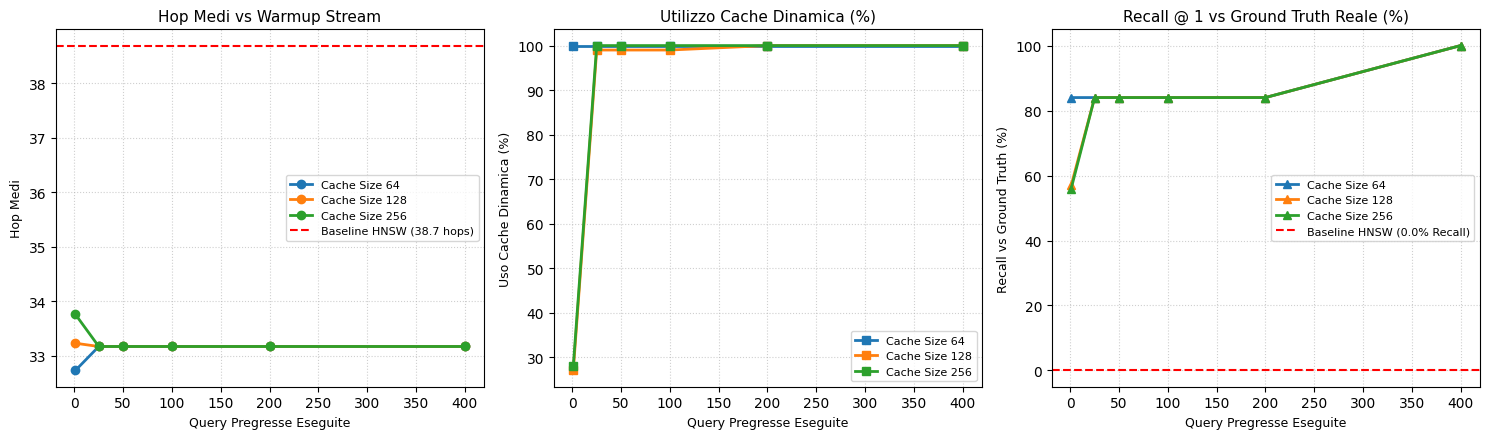

In [13]:
# Esecuzione del benchmark
checkpoints_list = [1, 25, 50, 100, 200, 400]
cache_sizes_list = [64, 128, 256]

df_results, baseline_hops = benchmark_cache_dynamics(
    hnsw_index=hnsw_index,
    data=data,
    queries=query_set,
    cache_sizes=cache_sizes_list,
    checkpoints=checkpoints_list,
    n_test_queries=100,
    ef_search=32
)

# Visualizzazione tabellare completa
display(df_results)

# Plot 1: Hop Medi vs Warmup
plt.figure(figsize=(15, 4.5))

plt.subplot(1, 3, 1)
for c_size in cache_sizes_list:
    subset = df_results[df_results["Cache Size"] == c_size]
    plt.plot(
        subset["Query Eseguite"],
        subset["Hop Medi"],
        marker='o',
        linewidth=2,
        label=f"Cache Size {c_size}"
    )

plt.axhline(
    y=baseline_hops,
    color='r',
    linestyle='--',
    linewidth=1.5,
    label=f"Baseline HNSW ({baseline_hops:.1f} hops)"
)
plt.title("Hop Medi vs Warmup Stream", fontsize=11)
plt.xlabel("Query Pregresse Eseguite", fontsize=9)
plt.ylabel("Hop Medi", fontsize=9)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=8)

# Plot 2: Tasso di Utilizzo Cache Dinamica
plt.subplot(1, 3, 2)
for c_size in cache_sizes_list:
    subset = df_results[df_results["Cache Size"] == c_size]
    plt.plot(
        subset["Query Eseguite"],
        subset["Uso Cache Dinamica (%)"],
        marker='s',
        linewidth=2,
        label=f"Cache Size {c_size}"
    )

plt.title("Utilizzo Cache Dinamica (%)", fontsize=11)
plt.xlabel("Query Pregresse Eseguite", fontsize=9)
plt.ylabel("Uso Cache Dinamica (%)", fontsize=9)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=8)

# Plot 3: Recall vs Ground Truth Reale (1-NN Esatto)
plt.subplot(1, 3, 3)
for c_size in cache_sizes_list:
    subset = df_results[df_results["Cache Size"] == c_size]
    plt.plot(
        subset["Query Eseguite"],
        subset["Recall vs GT Reale (%)"],
        marker='^',
        linewidth=2,
        label=f"Cache Size {c_size}"
    )

plt.axhline(
    y=0.0,
    color='r',
    linestyle='--',
    linewidth=1.5,
    label="Baseline HNSW (0.0% Recall)"
)
plt.title("Recall @ 1 vs Ground Truth Reale (%)", fontsize=11)
plt.xlabel("Query Pregresse Eseguite", fontsize=9)
plt.ylabel("Recall vs Ground Truth (%)", fontsize=9)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()


### 4. **Resilience Analysis under Non-Stationary Query Workload Drift**

Real-world search workloads are non-stationary: the underlying query distribution shifts over time as user interests, temporal trends, or active topics change. 

In this experiment, we study the **adaptability and resilience of the dynamic cache** under non-stationary query streams.
- **Workload Drift Simulation**: Queries arrive in sequential phases $t = 1, 2, \dots, P$. In each phase, the query distribution parameters change randomly:
  - The number of query clusters $K_t$ varies randomly between $1$ and $8$.
  - The power-law exponent $\gamma_t$ varies randomly between $1.5$ and $4.0$.
  - Cluster centers are re-sampled across the feature bounding box.
- **Evaluation Goals**:
  - Evaluate how quickly the dynamic LRU buffer adapts to distribution shifts.
  - Determine the minimum dynamic cache capacity $D$ (with total capacity fixed at $C = 64$) required to maintain:
    1. **Low Search Hops**: Significant reduction in hops compared to baseline HNSW.
    2. **High Ground Truth 1-NN Recall**: 100% (or near 100%) accuracy relative to exact brute-force L2 Ground Truth.



[*] Generazione stream query non-stazionario (6 fasi x 100 query = 600 query totali)...
[*] Calcolo Ground Truth 1-NN reale via brute-force su 600 query...
[*] Esecuzione Baseline HNSW senza cache su stream non-stazionario...
[*] Baseline HNSW: Hop Medi = 34.28 | Recall @ 1 vs GT = 26.5%

=== RISULTATI RESILIENZA AL WORKLOAD DRIFT (Capacità Totale C = 64) ===


,Capacità Totale (C),Cache Dinamica (D),Cache Statica (S),Hops Medi,Risparmio Hops (%),Recall @ 1 vs GT (%),Uso Cache Dinamica (%),Uso Cache Statica (%)
0,64,0,64,33.70,1.7,58.8,0.0,100.0
1,64,4,60,32.94,3.9,31.2,98.0,2.0
2,64,8,56,32.89,4.0,30.3,99.8,0.2
3,64,16,48,32.95,3.9,31.7,99.8,0.2
4,64,32,32,33.34,2.7,71.5,99.5,0.5
5,64,64,0,32.95,3.9,31.7,99.8,0.0


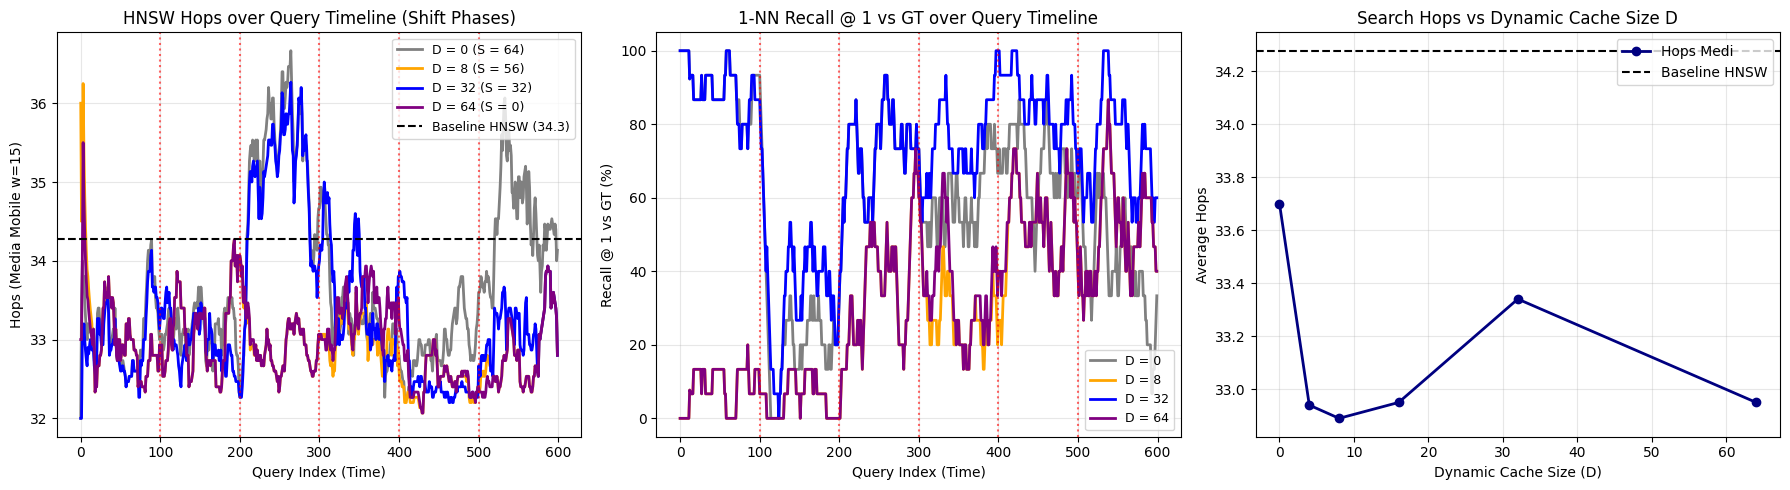

In [14]:
# Analisi della Resilienza della Cache Dinamica al Variare della Distribuzione delle Query (Drift Non-Stazionario)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def generate_drifting_query_stream(data, n_phases=6, queries_per_phase=100, random_state=42):
    """
    Genera uno stream sequenziale di query non-stazionario suddiviso in n_phases.
    In ogni fase cambiano randomicamente:
    - n_clusters (es. da 1 a 8)
    - exponent (gamma della power law, es. tra 1.5 e 4.0)
    - le posizioni dei centri nella bounding box
    """
    rng = np.random.default_rng(random_state)
    all_queries = []
    phase_boundaries = []
    phase_params = []
    
    current_idx = 0
    for phase in range(n_phases):
        n_clusters = int(rng.integers(1, 9))
        exponent = float(rng.uniform(1.5, 4.0))
        constant = float(rng.uniform(1.0, 3.0))
        phase_seed = int(rng.integers(0, 100000))
        
        q_phase = generate_queries(
            data=data,
            n_queries=queries_per_phase,
            n_clusters=n_clusters,
            exponent=exponent,
            constant=constant,
            random_state=phase_seed
        )
        all_queries.append(q_phase)
        current_idx += queries_per_phase
        if phase < n_phases - 1:
            phase_boundaries.append(current_idx)
        phase_params.append({'phase': phase+1, 'n_clusters': n_clusters, 'exponent': round(exponent, 2)})
        
    return np.vstack(all_queries), phase_boundaries, phase_params

# Parametri esperimento drift
n_phases = 6
queries_per_phase = 100
total_capacity = 64
dynamic_sizes = [0, 4, 8, 16, 32, 64]
ef_search = 32

print(f"[*] Generazione stream query non-stazionario ({n_phases} fasi x {queries_per_phase} query = {n_phases*queries_per_phase} query totali)...")
drift_queries, phase_boundaries, phase_params = generate_drifting_query_stream(
    data=data, n_phases=n_phases, queries_per_phase=queries_per_phase, random_state=42
)

total_queries = len(drift_queries)

# 1. Calcolo Ground Truth Brute-Force
print(f"[*] Calcolo Ground Truth 1-NN reale via brute-force su {total_queries} query...")
gt_nodes = []
for q in drift_queries:
    dists = np.linalg.norm(data - q, axis=1)**2
    gt_nodes.append(np.argmin(dists))
gt_nodes = np.array(gt_nodes)

# 2. Baseline HNSW Senza Cache
print("[*] Esecuzione Baseline HNSW senza cache su stream non-stazionario...")
hnsw_hops = []
hnsw_recall_gt = []
for idx, q in enumerate(drift_queries):
    res = hnsw_index.search(q, ef=ef_search)
    hnsw_hops.append(res["hops"])
    hnsw_recall_gt.append(1.0 if res["node"] == gt_nodes[idx] else 0.0)

baseline_avg_hops = float(np.mean(hnsw_hops))
baseline_avg_recall = float(np.mean(hnsw_recall_gt)) * 100.0

print(f"[*] Baseline HNSW: Hop Medi = {baseline_avg_hops:.2f} | Recall @ 1 vs GT = {baseline_avg_recall:.1f}%")

# 3. Benchmark Cache con Variazione della Dimensione Dinamica D
summary_rows = []
time_series_data = {}

for d_size in dynamic_sizes:
    s_size = total_capacity - d_size
    cache = CustomSplitCache(data=data, static_size=s_size, dynamic_size=d_size, random_state=42)
    
    q_hops = []
    q_recall_gt = []
    sources = []
    
    for idx, q in enumerate(drift_queries):
        ep_node, ep_dist, source = cache.get_best_entry_point(q)
        if ep_node is not None and source in ['dynamic', 'static']:
            res = hnsw_index.search(q, ef=ef_search, custom_entry_id=ep_node, enter_at_layer_zero=True)
        else:
            res = hnsw_index.search(q, ef=ef_search)
            
        q_hops.append(res["hops"])
        q_recall_gt.append(1.0 if res["node"] == gt_nodes[idx] else 0.0)
        sources.append(source)
        
        # Aggiornamento cache dinamica LRU
        cache.update_dynamic(res["node"])
        
    time_series_data[d_size] = {
        "hops": q_hops,
        "recall": q_recall_gt,
        "sources": sources
    }
    
    avg_hops = float(np.mean(q_hops))
    hop_saving = ((baseline_avg_hops - avg_hops) / baseline_avg_hops) * 100.0
    avg_recall = float(np.mean(q_recall_gt)) * 100.0
    dyn_usage = (sources.count("dynamic") / len(sources)) * 100.0 if "dynamic" in sources else 0.0
    stat_usage = (sources.count("static") / len(sources)) * 100.0 if "static" in sources else 0.0
    
    summary_rows.append({
        "Capacità Totale (C)": total_capacity,
        "Cache Dinamica (D)": d_size,
        "Cache Statica (S)": s_size,
        "Hops Medi": round(avg_hops, 2),
        "Risparmio Hops (%)": round(hop_saving, 1),
        "Recall @ 1 vs GT (%)": round(avg_recall, 1),
        "Uso Cache Dinamica (%)": round(dyn_usage, 1),
        "Uso Cache Statica (%)": round(stat_usage, 1)
    })

df_drift_summary = pd.DataFrame(summary_rows)

print("\n=== RISULTATI RESILIENZA AL WORKLOAD DRIFT (Capacità Totale C = 64) ===")
display(df_drift_summary)

# Visualizzazione Grafica a 3 Subplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Hops nel tempo con markers per cambio di fase
ax1 = axes[0]
colors = {0: 'gray', 4: 'red', 8: 'orange', 16: 'green', 32: 'blue', 64: 'purple'}

# Smoothing media mobile window 15 per chiarezza grafica
window_size = 15
for d_size in [0, 8, 32, 64]:
    hops_series = pd.Series(time_series_data[d_size]["hops"]).rolling(window=window_size, min_periods=1).mean()
    ax1.plot(hops_series, label=f"D = {d_size} (S = {total_capacity - d_size})", color=colors[d_size], linewidth=2)

ax1.axhline(baseline_avg_hops, color='black', linestyle='--', label=f'Baseline HNSW ({baseline_avg_hops:.1f})')
for b in phase_boundaries:
    ax1.axvline(b, color='red', linestyle=':', alpha=0.6)

ax1.set_title("HNSW Hops over Query Timeline (Shift Phases)")
ax1.set_xlabel("Query Index (Time)")
ax1.set_ylabel("Hops (Media Mobile w=15)")
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Recall vs GT nel tempo
ax2 = axes[1]
for d_size in [0, 8, 32, 64]:
    rec_series = pd.Series(time_series_data[d_size]["recall"]).rolling(window=window_size, min_periods=1).mean() * 100.0
    ax2.plot(rec_series, label=f"D = {d_size}", color=colors[d_size], linewidth=2)

for b in phase_boundaries:
    ax2.axvline(b, color='red', linestyle=':', alpha=0.6)

ax2.set_title("1-NN Recall @ 1 vs GT over Query Timeline")
ax2.set_xlabel("Query Index (Time)")
ax2.set_ylabel("Recall @ 1 vs GT (%)")
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3: Trade-off Hops vs Dimensione Cache Dinamica D
ax3 = axes[2]
ax3.plot(df_drift_summary["Cache Dinamica (D)"], df_drift_summary["Hops Medi"], marker='o', color='navy', linewidth=2, label="Hops Medi")
ax3.axhline(baseline_avg_hops, color='black', linestyle='--', label="Baseline HNSW")
ax3.set_title("Search Hops vs Dynamic Cache Size D")
ax3.set_xlabel("Dynamic Cache Size (D)")
ax3.set_ylabel("Average Hops")
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("C:/Users/leona/.gemini/antigravity/brain/f3da8da6-f7ce-4d35-9220-13be93f867d7/drift_resilience_plot.png", dpi=150, bbox_inches="tight")
plt.show()



Modifiche/aggiunte:
- **TODO** Fare tests al variare del parametro dynamic-to-static: X
- **TODO** Vedere quanto spesso vengono usati i vettori in cache dinamica: X
- **TODO** Fare confronto tra veri 1-NN e i risultati nostri e di HNSW: X
- **TODO** Vedere come il numero di cluster della query distribution interagisce con la lunghezza ottimale della cache dinamica: X
- **TODO** Fare test di debugging chiedendo sempre la stessa query: X
- **TODO** Contare il numero di hop per livello (data la query). Auspicabilmente, ci sono pochi hop nell'ultimo livello.
-------------------------------------------------------------------
Nuove idee:
- **TODO** Tenere in cache statica i vettori del livello più alto
- **TODO** Pensare a una forma di biased skip list in salsa HNSW
(aggiungere i medoidi con probabilità pari alla densità delle query che hanno quel medoide come più vicino)
-------------------------------------------------------------------

